# Quantitative Stock Analysis Using Technical Indicators

## Week 1 Challenge — Task 2

This notebook analyzes historical stock price data using technical indicators such as:
- Simple Moving Average (SMA)
- Exponential Moving Average (EMA)
- Daily Returns
- Relative Strength Index (RSI)
- MACD

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

In [2]:
stock_df = pd.read_csv("../data/raw/sample_stocks.csv")

stock_df.head()

FileNotFoundError: [Errno 2] No such file or directory: '../data/raw/sample_stocks.csv'

In [3]:
import pandas as pd
import os

stock_files = {
    "AAPL": "../data/raw/AAPL.csv",
    "AMZN": "../data/raw/AMZN.csv",
    "GOOG": "../data/raw/GOOG.csv",
    "META": "../data/raw/META.csv",
    "NVDA": "../data/raw/NVDA.csv"
}

stock_data = []

for stock, file_path in stock_files.items():
    df = pd.read_csv(file_path)
    df["Stock"] = stock
    stock_data.append(df)

stock_df = pd.concat(stock_data, ignore_index=True)

stock_df.head()

,Date,Close,High,Low,Open,Volume,Stock
0,2009-01-02,2.721686,2.730385,2.554037,2.575630,746015200,AAPL
1,2009-01-05,2.836553,2.884539,2.780469,2.794266,1181608400,AAPL
2,2009-01-06,2.789767,2.914229,2.770872,2.877641,1289310400,AAPL
3,2009-01-07,2.729484,2.774170,2.706990,2.753477,753048800,AAPL
4,2009-01-08,2.780169,2.793666,2.700393,2.712090,673500800,AAPL


In [4]:
stock_df["Stock"].value_counts()

Stock
AAPL    3774
AMZN    3774
GOOG    3774
NVDA    3774
META    2923
Name: count, dtype: int64

In [5]:
stock_df.tail()

,Date,Close,High,Low,Open,Volume,Stock
18014,2023-12-22,48.805527,49.358247,48.442706,49.170342,252507000,NVDA
18015,2023-12-26,49.254299,49.575137,48.935459,48.943454,244200000,NVDA
18016,2023-12-27,49.392231,49.655100,49.060397,49.486186,233648000,NVDA
18017,2023-12-28,49.497185,49.859003,49.387239,49.618126,246587000,NVDA
18018,2023-12-29,49.497185,49.971949,48.726571,49.788039,389293000,NVDA


In [6]:
stock_df["Date"] = pd.to_datetime(stock_df["Date"])

In [7]:
stock_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 18019 entries, 0 to 18018
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    18019 non-null  datetime64[us]
 1   Close   18019 non-null  float64       
 2   High    18019 non-null  float64       
 3   Low     18019 non-null  float64       
 4   Open    18019 non-null  float64       
 5   Volume  18019 non-null  int64         
 6   Stock   18019 non-null  str           
dtypes: datetime64[us](1), float64(4), int64(1), str(1)
memory usage: 985.5 KB


In [8]:
stock_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 18019 entries, 0 to 18018
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    18019 non-null  datetime64[us]
 1   Close   18019 non-null  float64       
 2   High    18019 non-null  float64       
 3   Low     18019 non-null  float64       
 4   Open    18019 non-null  float64       
 5   Volume  18019 non-null  int64         
 6   Stock   18019 non-null  str           
dtypes: datetime64[us](1), float64(4), int64(1), str(1)
memory usage: 985.5 KB


In [9]:
stock_df = stock_df.sort_values(["Stock", "Date"])

In [10]:
stock_df["Daily_Return"] = (
    stock_df.groupby("Stock")["Close"]
    .pct_change() * 100
)

In [11]:
stock_df["SMA_20"] = (
    stock_df.groupby("Stock")["Close"]
    .transform(lambda x: x.rolling(window=20).mean())
)

stock_df["SMA_50"] = (
    stock_df.groupby("Stock")["Close"]
    .transform(lambda x: x.rolling(window=50).mean())
)

In [12]:
stock_df[[
    "Date",
    "Stock",
    "Close",
    "SMA_20",
    "SMA_50"
]].tail()

,Date,Stock,Close,SMA_20,SMA_50
18014,2023-12-22,NVDA,48.805527,47.706983,46.257777
18015,2023-12-26,NVDA,49.254299,47.759019,46.334178
18016,2023-12-27,NVDA,49.392231,47.838989,46.400666
18017,2023-12-28,NVDA,49.497185,47.908266,46.512367
18018,2023-12-29,NVDA,49.497185,48.046003,46.658888


In [13]:
aapl_df = stock_df[stock_df["Stock"] == "AAPL"]

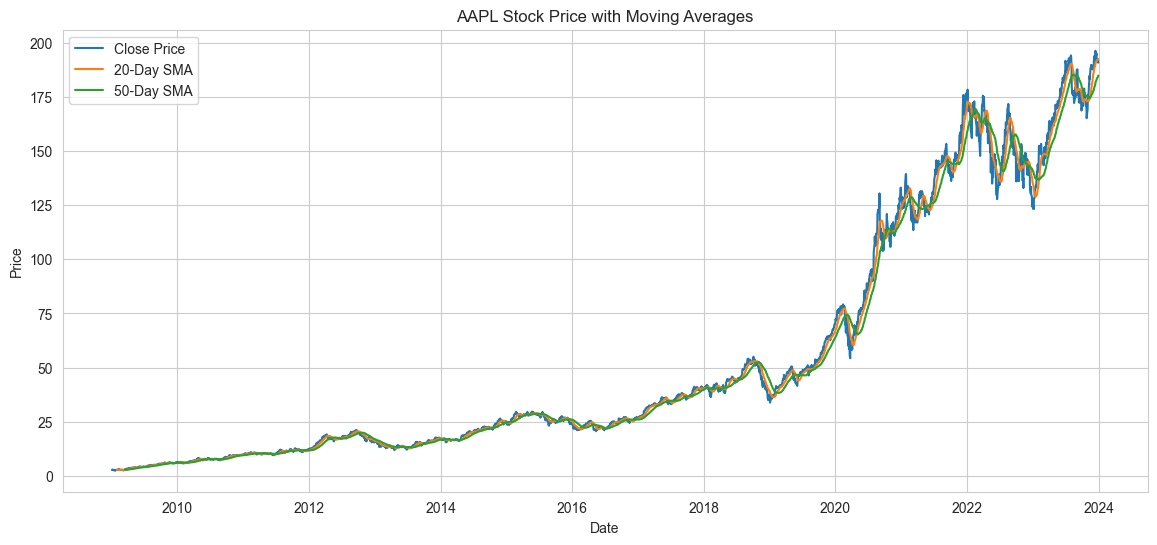

In [14]:
plt.figure(figsize=(14,6))

plt.plot(aapl_df["Date"], aapl_df["Close"], label="Close Price")
plt.plot(aapl_df["Date"], aapl_df["SMA_20"], label="20-Day SMA")
plt.plot(aapl_df["Date"], aapl_df["SMA_50"], label="50-Day SMA")

plt.title("AAPL Stock Price with Moving Averages")
plt.xlabel("Date")
plt.ylabel("Price")

plt.legend()

plt.show()

In [15]:
stock_df["EMA_20"] = (
    stock_df.groupby("Stock")["Close"]
    .transform(lambda x: x.ewm(span=20, adjust=False).mean())
)

stock_df["EMA_50"] = (
    stock_df.groupby("Stock")["Close"]
    .transform(lambda x: x.ewm(span=50, adjust=False).mean())
)

In [16]:
aapl_df = stock_df[stock_df["Stock"] == "AAPL"]

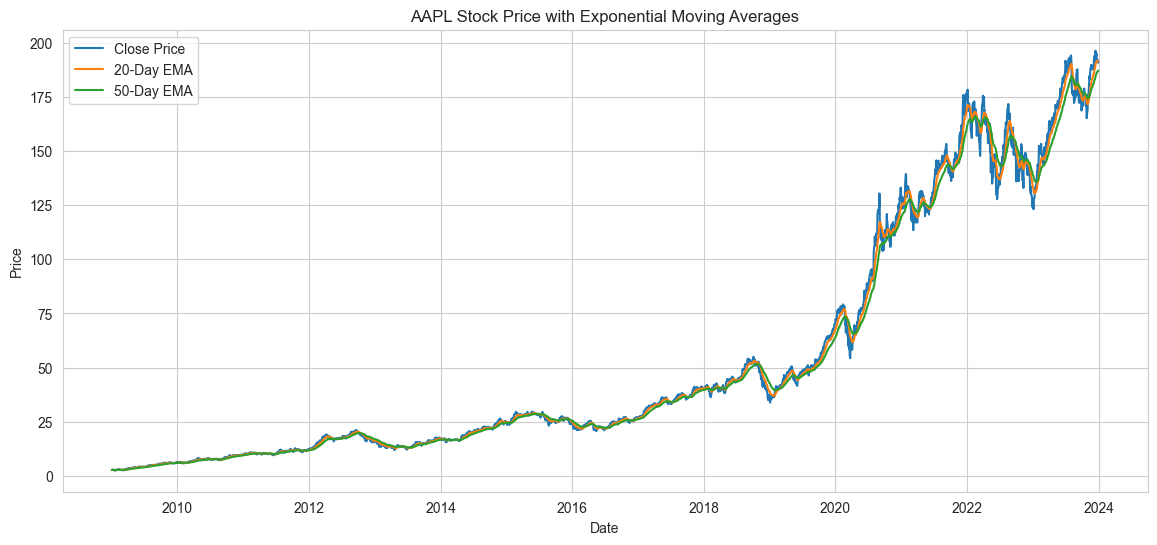

In [17]:
plt.figure(figsize=(14,6))

plt.plot(aapl_df["Date"], aapl_df["Close"], label="Close Price")
plt.plot(aapl_df["Date"], aapl_df["EMA_20"], label="20-Day EMA")
plt.plot(aapl_df["Date"], aapl_df["EMA_50"], label="50-Day EMA")

plt.title("AAPL Stock Price with Exponential Moving Averages")
plt.xlabel("Date")
plt.ylabel("Price")

plt.legend()

plt.show()

In [18]:
def calculate_rsi(data, window=14):
    
    delta = data.diff()

    gain = delta.where(delta > 0, 0)
    loss = -delta.where(delta < 0, 0)

    avg_gain = gain.rolling(window=window).mean()
    avg_loss = loss.rolling(window=window).mean()

    rs = avg_gain / avg_loss

    rsi = 100 - (100 / (1 + rs))

    return rsi

In [19]:
stock_df["RSI"] = (
    stock_df.groupby("Stock")["Close"]
    .transform(lambda x: calculate_rsi(x))
)

In [20]:
aapl_df = stock_df[stock_df["Stock"] == "AAPL"]

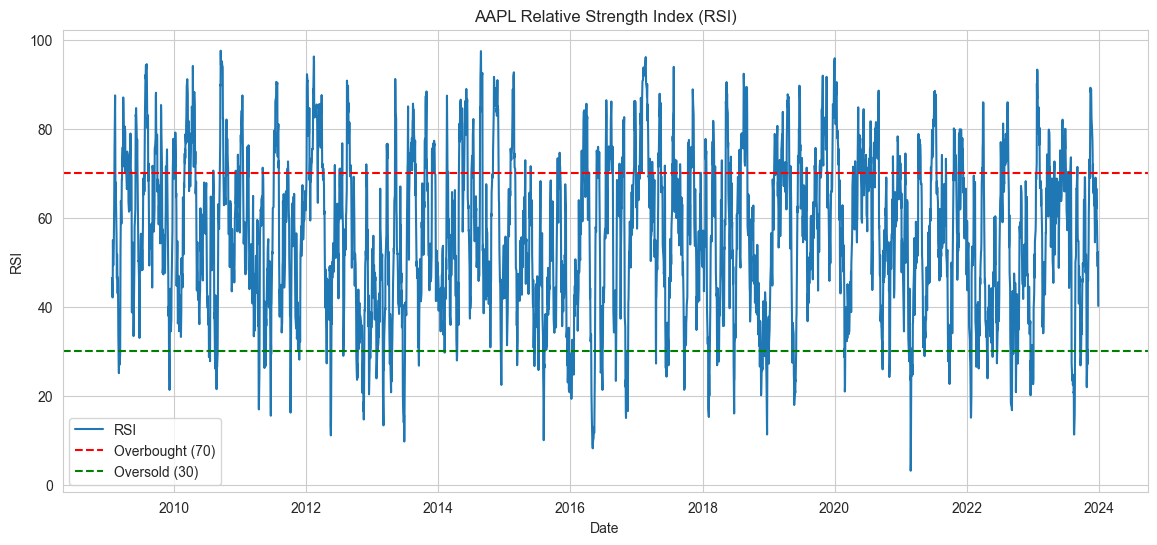

In [21]:
plt.figure(figsize=(14,6))

plt.plot(aapl_df["Date"], aapl_df["RSI"], label="RSI")

plt.axhline(70, color='red', linestyle='--', label='Overbought (70)')
plt.axhline(30, color='green', linestyle='--', label='Oversold (30)')

plt.title("AAPL Relative Strength Index (RSI)")
plt.xlabel("Date")
plt.ylabel("RSI")

plt.legend()

plt.show()

## RSI Interpretation

The RSI indicator helps identify momentum conditions in the market.

- Values above 70 may indicate overbought conditions.
- Values below 30 may indicate oversold conditions.
- RSI fluctuations provide insight into changing market momentum and potential reversal points.

In [22]:
stock_df["EMA_12"] = (
    stock_df.groupby("Stock")["Close"]
    .transform(lambda x: x.ewm(span=12, adjust=False).mean())
)

stock_df["EMA_26"] = (
    stock_df.groupby("Stock")["Close"]
    .transform(lambda x: x.ewm(span=26, adjust=False).mean())
)

stock_df["MACD"] = stock_df["EMA_12"] - stock_df["EMA_26"]

stock_df["MACD_Signal"] = (
    stock_df.groupby("Stock")["MACD"]
    .transform(lambda x: x.ewm(span=9, adjust=False).mean())
)

stock_df["MACD_Histogram"] = stock_df["MACD"] - stock_df["MACD_Signal"]

In [23]:
aapl_df = stock_df[stock_df["Stock"] == "AAPL"]

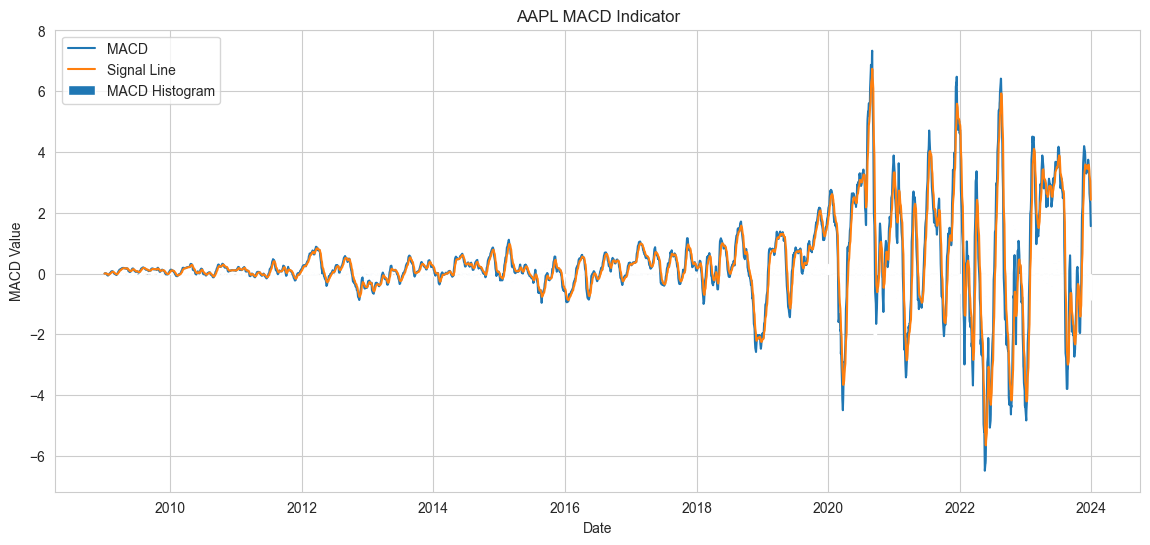

In [24]:
plt.figure(figsize=(14,6))

plt.plot(aapl_df["Date"], aapl_df["MACD"], label="MACD")
plt.plot(aapl_df["Date"], aapl_df["MACD_Signal"], label="Signal Line")
plt.bar(aapl_df["Date"], aapl_df["MACD_Histogram"], label="MACD Histogram")

plt.title("AAPL MACD Indicator")
plt.xlabel("Date")
plt.ylabel("MACD Value")

plt.legend()
plt.show()

## MACD Interpretation

MACD is used to identify momentum shifts and possible trend reversals.

- When MACD moves above the signal line, it may suggest bullish momentum.
- When MACD moves below the signal line, it may suggest bearish momentum.
- The histogram shows the strength of the gap between MACD and the signal line.

# Technical Indicator Insights

The technical indicators reveal several important market patterns:

- The moving averages smooth short-term volatility and highlight broader trends.
- EMA reacts faster to recent price changes compared to SMA.
- RSI identifies momentum extremes and possible reversal zones.
- MACD highlights bullish and bearish momentum shifts through signal-line crossovers.

Together, these indicators provide a stronger understanding of stock price behavior and market sentiment.

In [25]:
volatility = (
    stock_df.groupby("Stock")["Daily_Return"]
    .std()
    .sort_values(ascending=False)
)

volatility

Stock
NVDA    2.891729
META    2.527991
AMZN    2.182919
AAPL    1.801011
GOOG    1.733354
Name: Daily_Return, dtype: float64

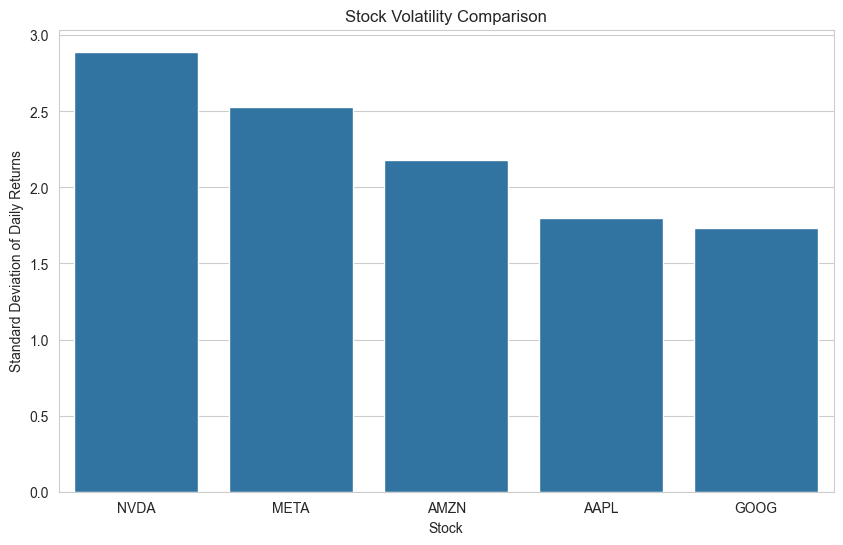

In [26]:
plt.figure(figsize=(10,6))

sns.barplot(
    x=volatility.index,
    y=volatility.values
)

plt.title("Stock Volatility Comparison")
plt.xlabel("Stock")
plt.ylabel("Standard Deviation of Daily Returns")

plt.show()

In [27]:
average_returns = (
    stock_df.groupby("Stock")["Daily_Return"]
    .mean()
    .sort_values(ascending=False)
)

average_returns

Stock
NVDA    0.187693
AMZN    0.130257
AAPL    0.128911
META    0.108187
GOOG    0.091017
Name: Daily_Return, dtype: float64

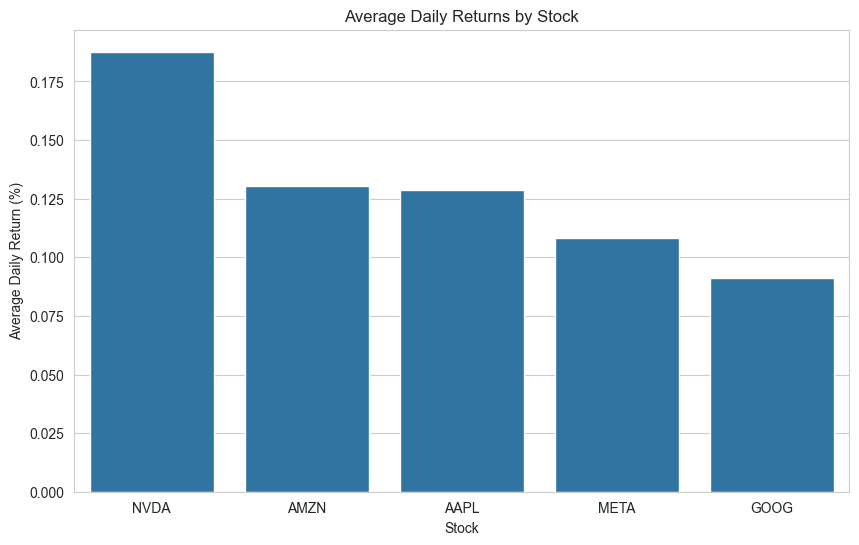

In [28]:
plt.figure(figsize=(10,6))

sns.barplot(
    x=average_returns.index,
    y=average_returns.values
)

plt.title("Average Daily Returns by Stock")
plt.xlabel("Stock")
plt.ylabel("Average Daily Return (%)")

plt.show()

# Limitations

Several limitations should be considered:

- Technical indicators are based on historical price data and may not fully predict future market behavior.
- External market factors such as geopolitical events, earnings announcements, and macroeconomic conditions are not captured directly.
- Indicators may generate false signals during periods of high volatility.
- The analysis does not account for transaction costs or trading constraints.